# SST Upwelling Binary Segmentation (2010 - 2019)
Generates violin plots of CDOM partitions (Upwelling vs Non-upwelling) by Month for the years 2010 through 2019.

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import warnings

# 1. Load the data
file_path = r'E:\satdata\Custom\yucatan_sst_chlor_cdomslope_ssl_bathy_2010-2019_v3.pkl'
try:
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
    df = data['data']
    print("Data loaded successfully.")
    
    # Ensure datetime index is parsed
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
        
except FileNotFoundError:
    print("Data file not found. Please check path.")

Data loaded successfully.


In [2]:
def process_and_plot_year(year):
    year_str = str(year)
    print(f"\n{'='*60}\nProcessing Year: {year_str}\n{'='*60}")
    
    if int(year) not in df.index.year.unique():
        print(f"No data for year {year_str}")
        return
        
    df_year = df[df.index.year == int(year)].copy()
    monthly_binary = {}
    
    # 1. Compute monthly means and their binary upwelling threshold 
    for m in range(1, 13):
        month_rows = df_year[df_year.index.month == m]
        month_grids = []
        for _, row in month_rows.iterrows():
            grid = row.get('sst')
            if grid is not None and not (isinstance(grid, float) and np.isnan(grid)):
                month_grids.append(np.array(grid, dtype=float))
                
        if month_grids:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore', category=RuntimeWarning)
                mean_month_sst = np.nanmean(np.stack(month_grids), axis=0)
                
            spatial_mean = np.nanmean(mean_month_sst)
            spatial_std = np.nanstd(mean_month_sst)
            threshold = spatial_mean - spatial_std
            
            binary_grid = np.zeros_like(mean_month_sst)
            binary_grid[mean_month_sst <= threshold] = 1
            binary_grid[np.isnan(mean_month_sst)] = np.nan
            monthly_binary[m] = binary_grid
        else:
            monthly_binary[m] = None

    # 2. Extract CDOM daily pixels
    all_month_labels = []
    all_month_is_upwelling = []
    all_month_s275 = []
    all_month_s300 = []
    all_month_a412 = []

    def _is_missing_grid(grid_obj):
        return grid_obj is None or (isinstance(grid_obj, float) and np.isnan(grid_obj))

    for m in range(1, 13):
        bin_grid = monthly_binary.get(m)
        if bin_grid is None or isinstance(bin_grid, float):
            continue
            
        bin_flat = bin_grid.flatten()
        month_rows = df_year[df_year.index.month == m]
        
        for _, row in month_rows.iterrows():
            s275 = row.get('cdom_slope_275_295')
            s300 = row.get('cdom_slope_300_600')
            a412 = row.get('cdom_412', row.get('cdom'))
            
            if any(_is_missing_grid(g) for g in [s275, s300, a412]):
                continue
                
            s275_flat = np.array(s275, dtype=float).flatten()
            s300_flat = np.array(s300, dtype=float).flatten()
            a412_flat = np.array(a412, dtype=float).flatten()
            
            valid_mask = (
                ~np.isnan(bin_flat) & 
                ~np.isnan(s275_flat) & 
                ~np.isnan(s300_flat) & 
                ~np.isnan(a412_flat) &
                (a412_flat > 0)
            )
            
            if not np.any(valid_mask):
                continue
                
            up_flags = bin_flat[valid_mask] == 1
            
            all_month_labels.extend([m] * int(np.sum(valid_mask)))
            all_month_is_upwelling.extend(up_flags)
            all_month_s275.extend(s275_flat[valid_mask])
            all_month_s300.extend(s300_flat[valid_mask])
            all_month_a412.extend(a412_flat[valid_mask])

    all_month_labels = np.array(all_month_labels, dtype=int)
    all_month_is_upwelling = np.array(all_month_is_upwelling, dtype=bool)
    all_month_s275 = np.array(all_month_s275)
    all_month_s300 = np.array(all_month_s300)
    all_month_a412 = np.array(all_month_a412)

    if all_month_labels.size == 0:
        print(f"No valid CDOM data found to plot for {year_str}.")
        return

    # 3. Plotting function for Violin Plots
    def plot_violin(values, var_title, y_unit):
        fig, ax = plt.subplots(figsize=(16, 6))
        
        up_data, non_data = [], []
        up_positions, non_positions = [], []
        tick_positions = []

        for month in range(1, 13):
            month_mask = all_month_labels == month
            up_vals = values[month_mask & (all_month_is_upwelling == True)]
            non_vals = values[month_mask & (all_month_is_upwelling == False)]
            
            up_vals = up_vals[~np.isnan(up_vals)]
            non_vals = non_vals[~np.isnan(non_vals)]

            center = month
            tick_positions.append(center)

            if up_vals.size > 0:
                up_data.append(up_vals)
                up_positions.append(center - 0.2)
            if non_vals.size > 0:
                non_data.append(non_vals)
                non_positions.append(center + 0.2)
                
        if up_data:
            vp_up = ax.violinplot(up_data, positions=up_positions, widths=0.35, showmeans=False, showmedians=True, showextrema=True)
            for pc in vp_up['bodies']:
                pc.set_facecolor('red'); pc.set_edgecolor('black'); pc.set_alpha(0.60)
            for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
                vp_up[partname].set_edgecolor('black'); vp_up[partname].set_linewidth(1.2)

        if non_data:
            vp_non = ax.violinplot(non_data, positions=non_positions, widths=0.35, showmeans=False, showmedians=True, showextrema=True)
            for pc in vp_non['bodies']:
                pc.set_facecolor('blue'); pc.set_edgecolor('black'); pc.set_alpha(0.60)
            for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
                vp_non[partname].set_edgecolor('black'); vp_non[partname].set_linewidth(1.2)

        ax.set_xticks(range(1, 13))
        ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
        ax.set_ylabel(y_unit)
        ax.set_title(f'{var_title}: Upwelling vs Non-Upwelling by Month ({year_str}) - Violin', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.25, linestyle='--')

        legend_handles = [
            Patch(facecolor='red', edgecolor='black', alpha=0.60, label='Upwelling (≤ -1σ)'),
            Patch(facecolor='blue', edgecolor='black', alpha=0.60, label='Other (> -1σ)'),
        ]
        ax.legend(handles=legend_handles, loc='best')

        plt.tight_layout()
        plt.show()

    plot_violin(all_month_s275, 'CDOM S275:295', 'm$^{-1}$')
    plot_violin(all_month_s300, 'CDOM S300:600', 'm$^{-1}$')
    plot_violin(all_month_a412, 'CDOM a(412)', 'm$^{-1}$')
    print(f"Generated violin plots for {year_str}.")


Processing Year: 2010


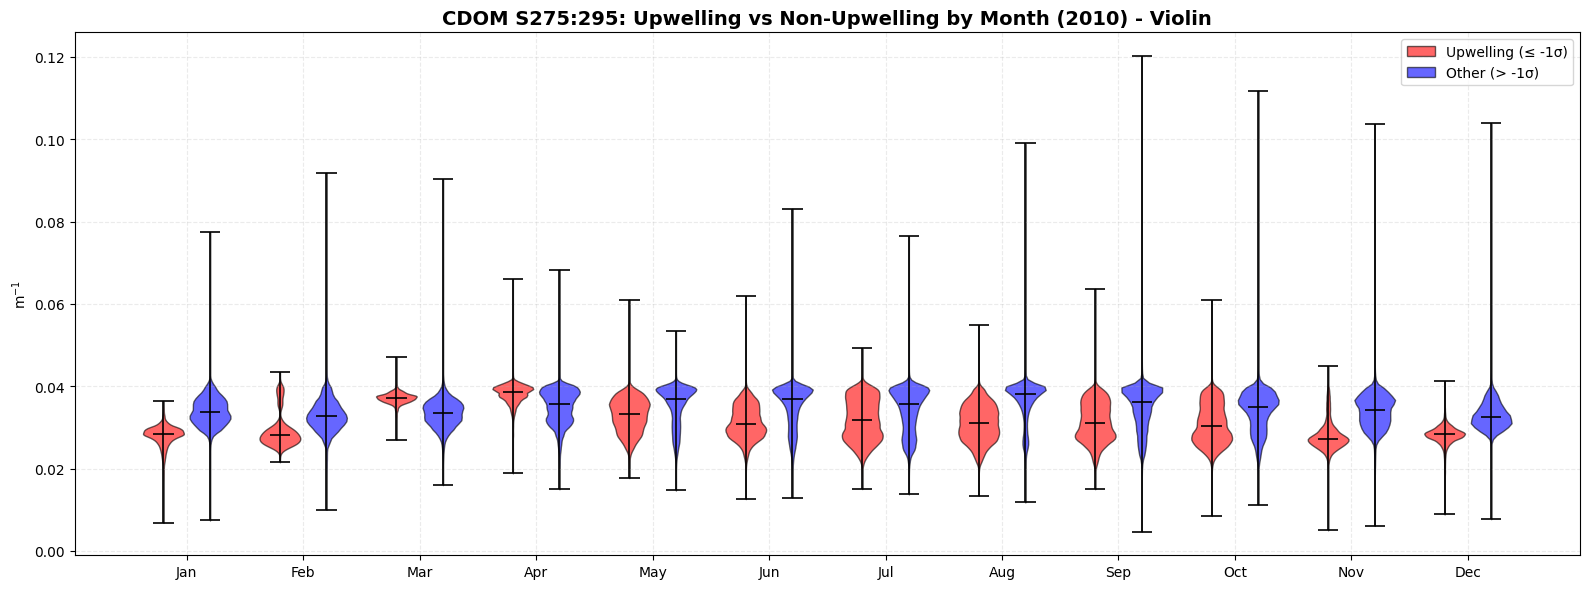

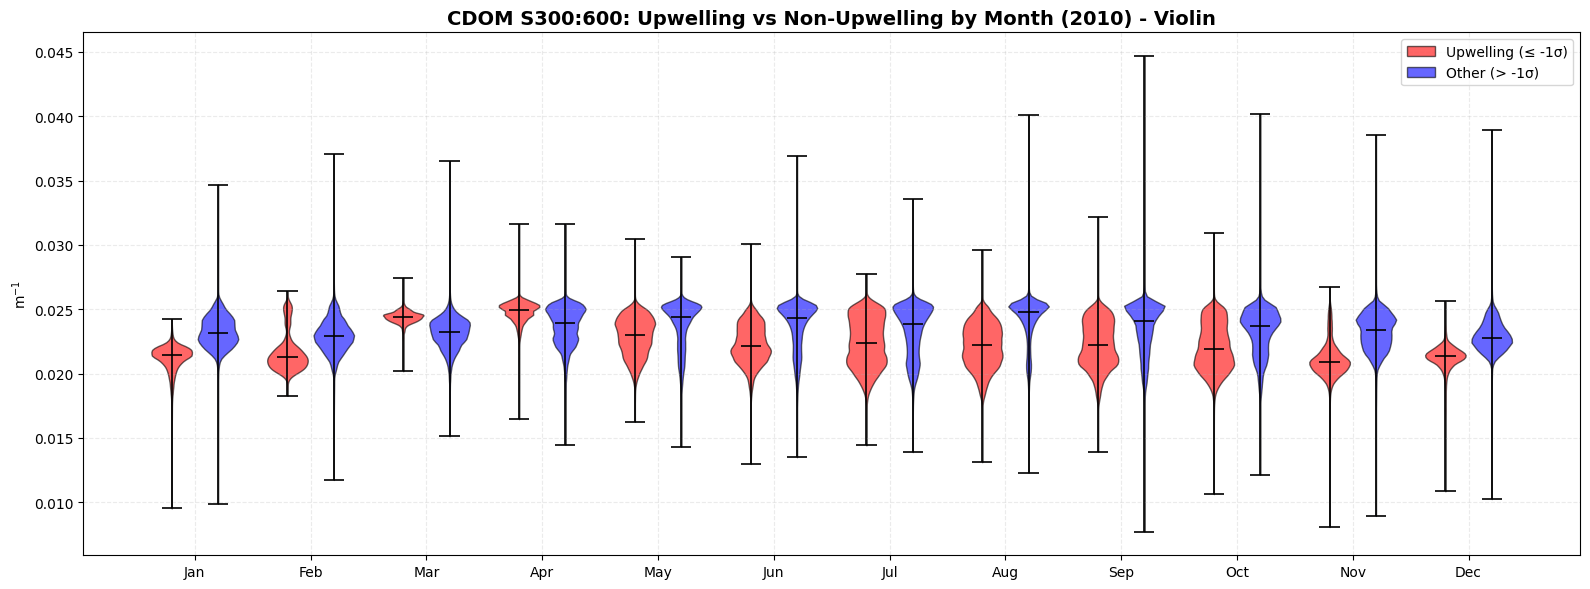

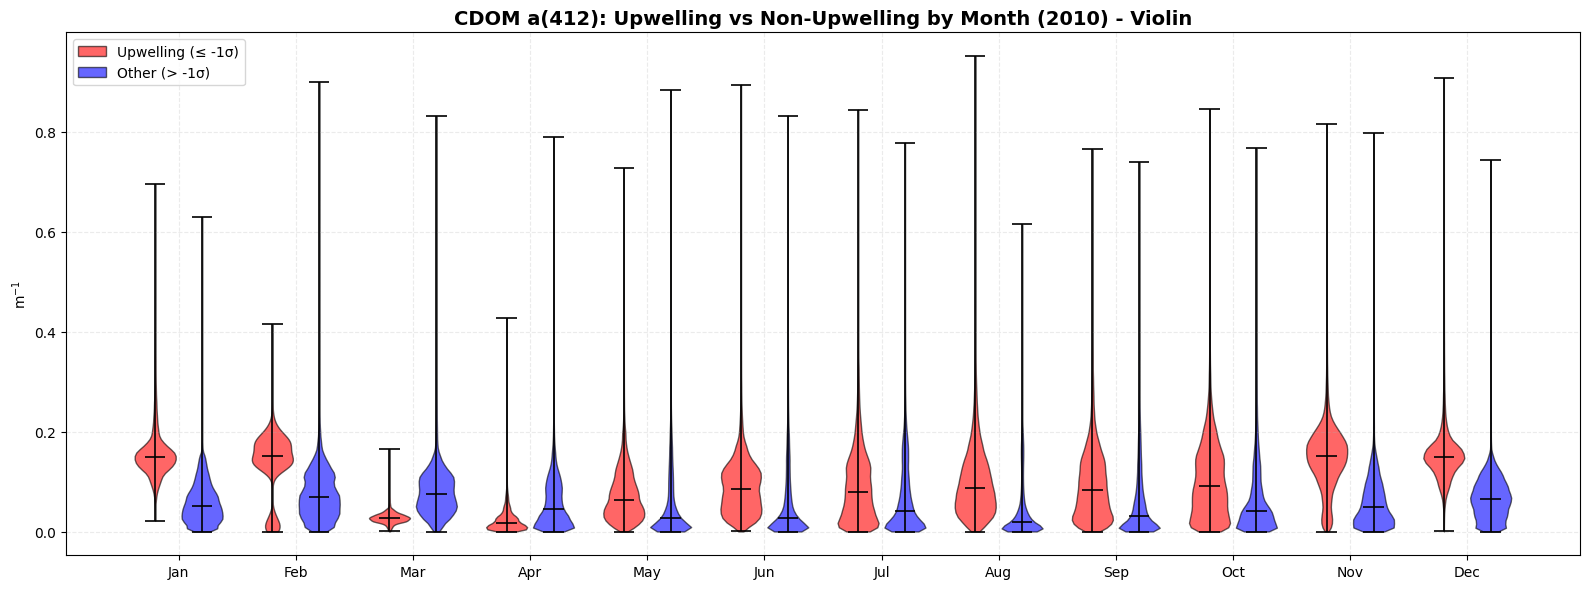

Generated violin plots for 2010.

Processing Year: 2011


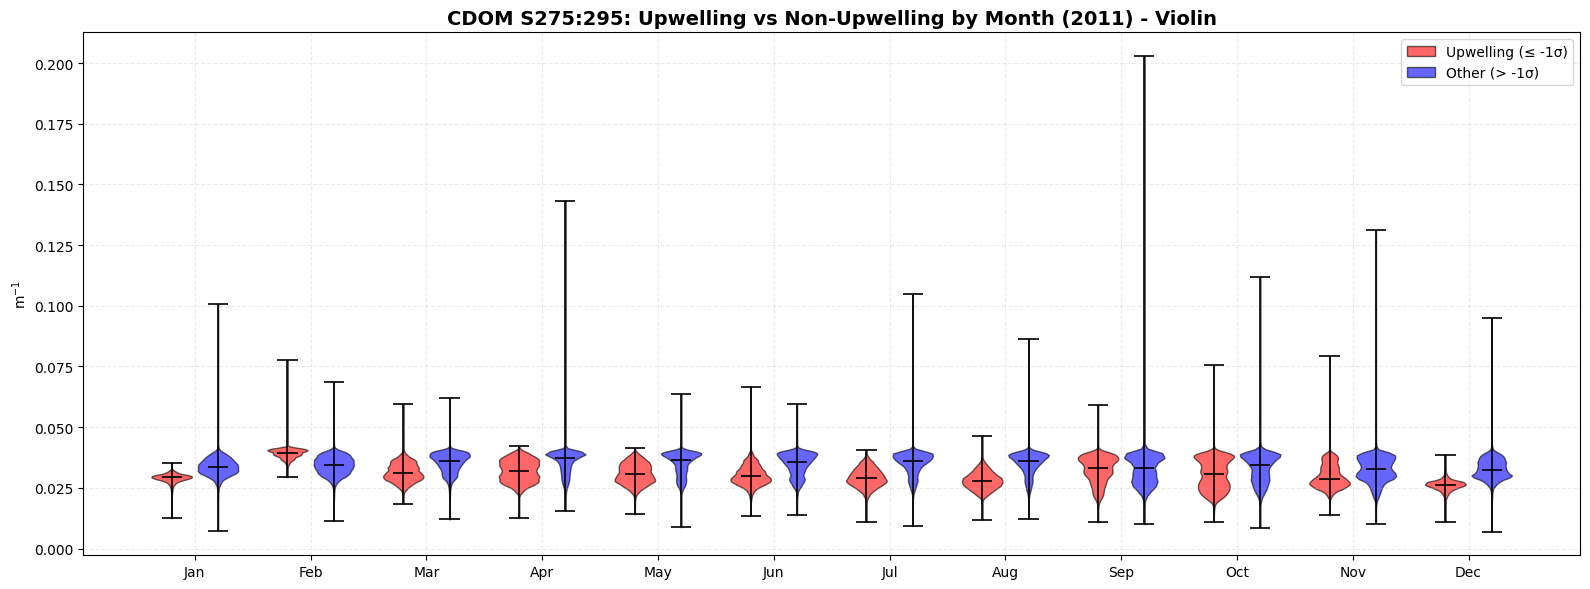

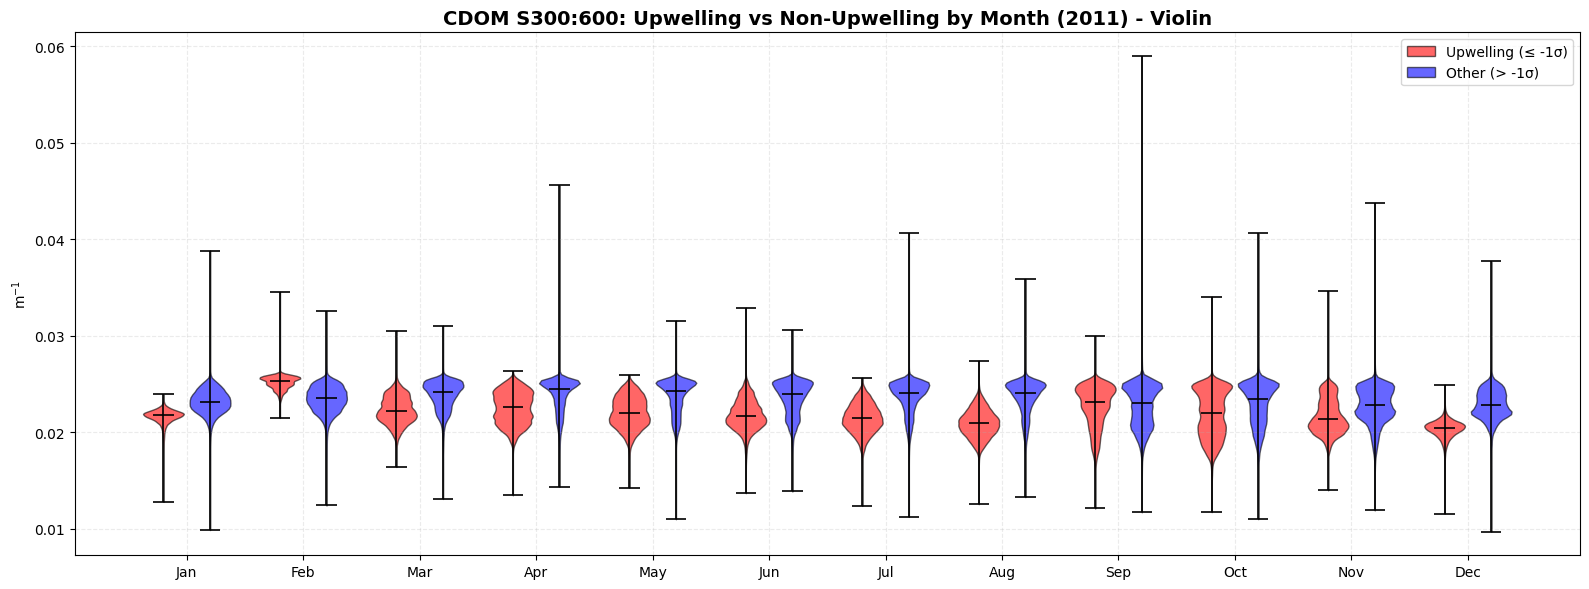

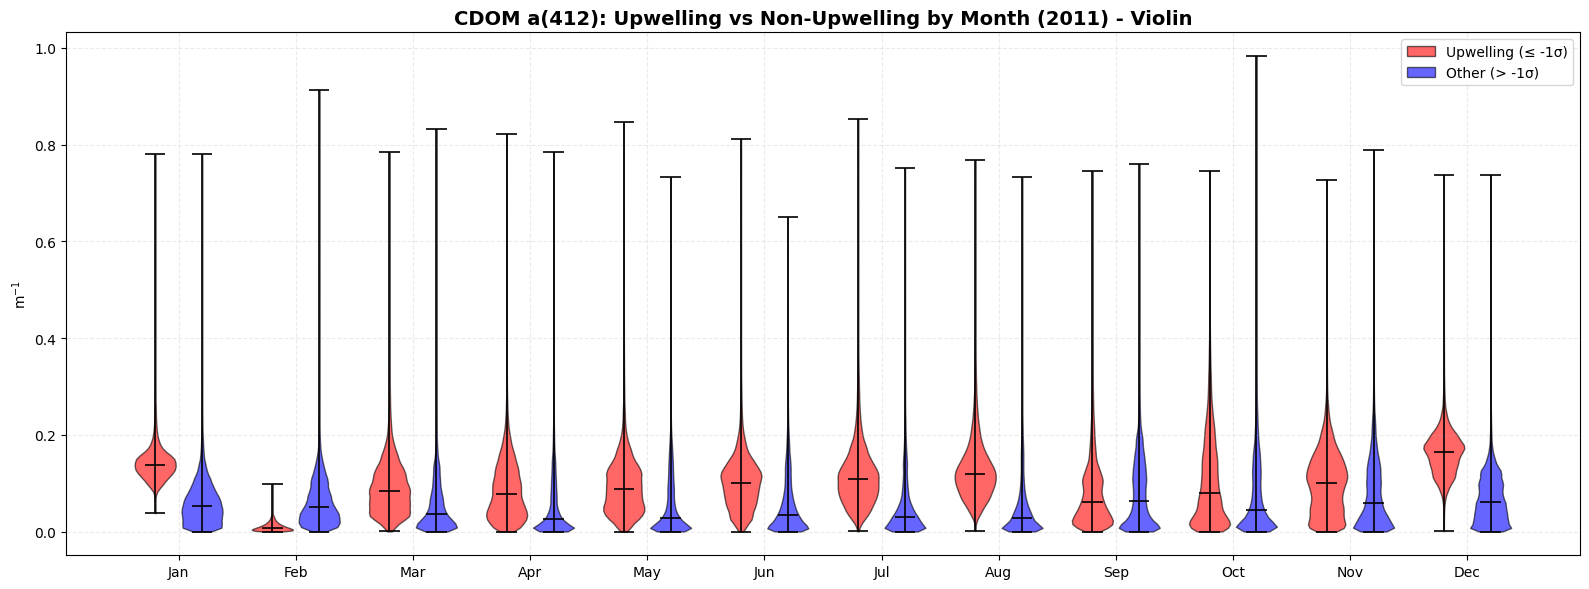

Generated violin plots for 2011.

Processing Year: 2012


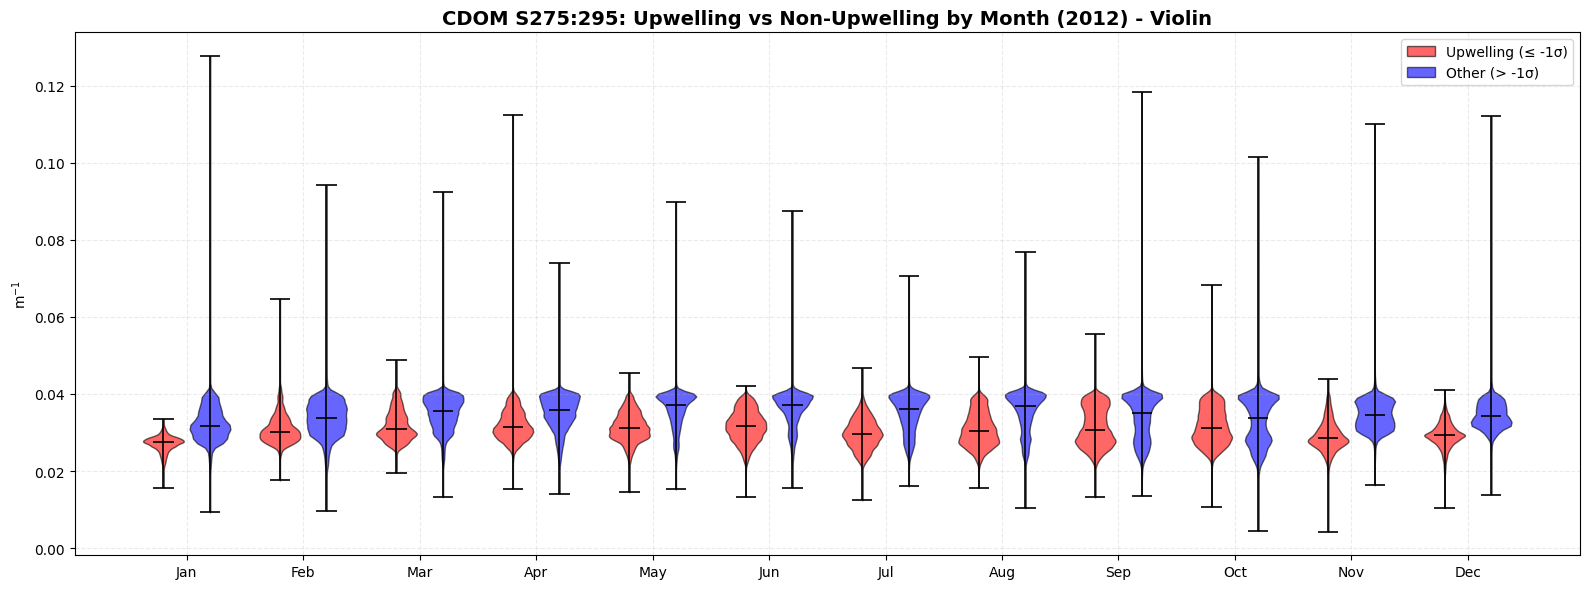

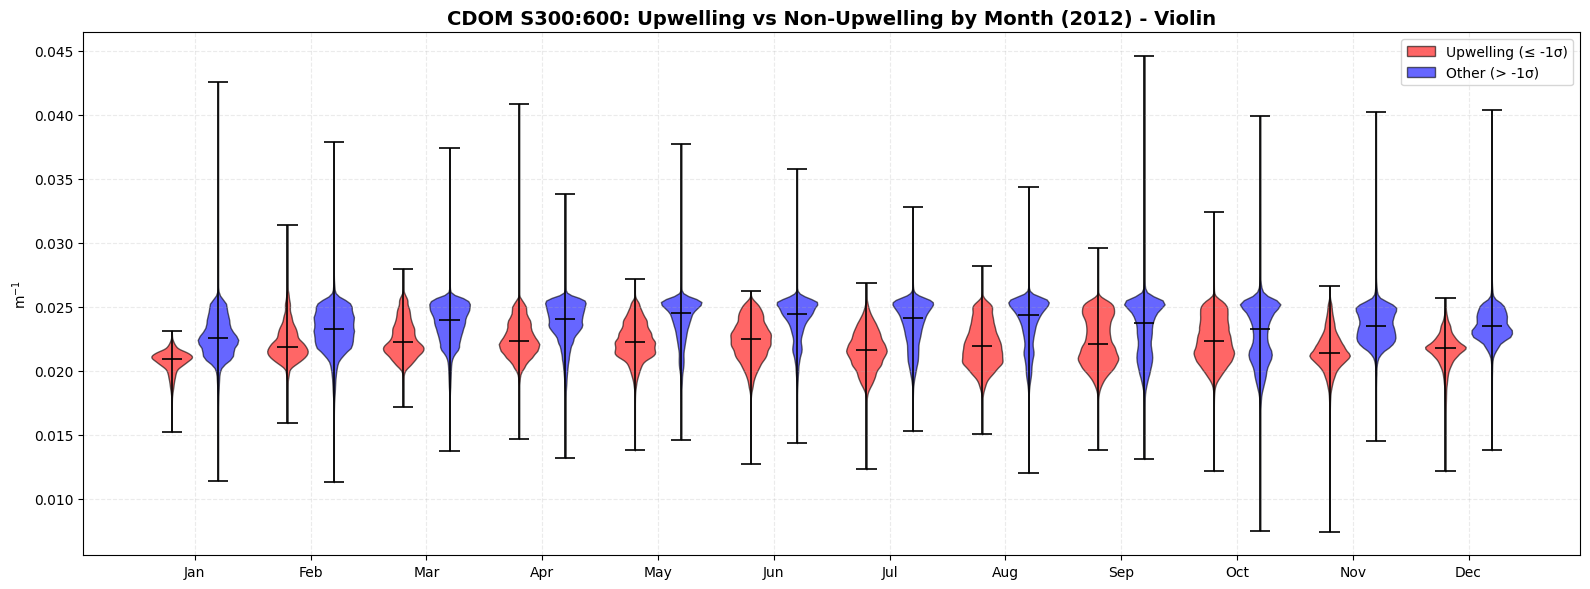

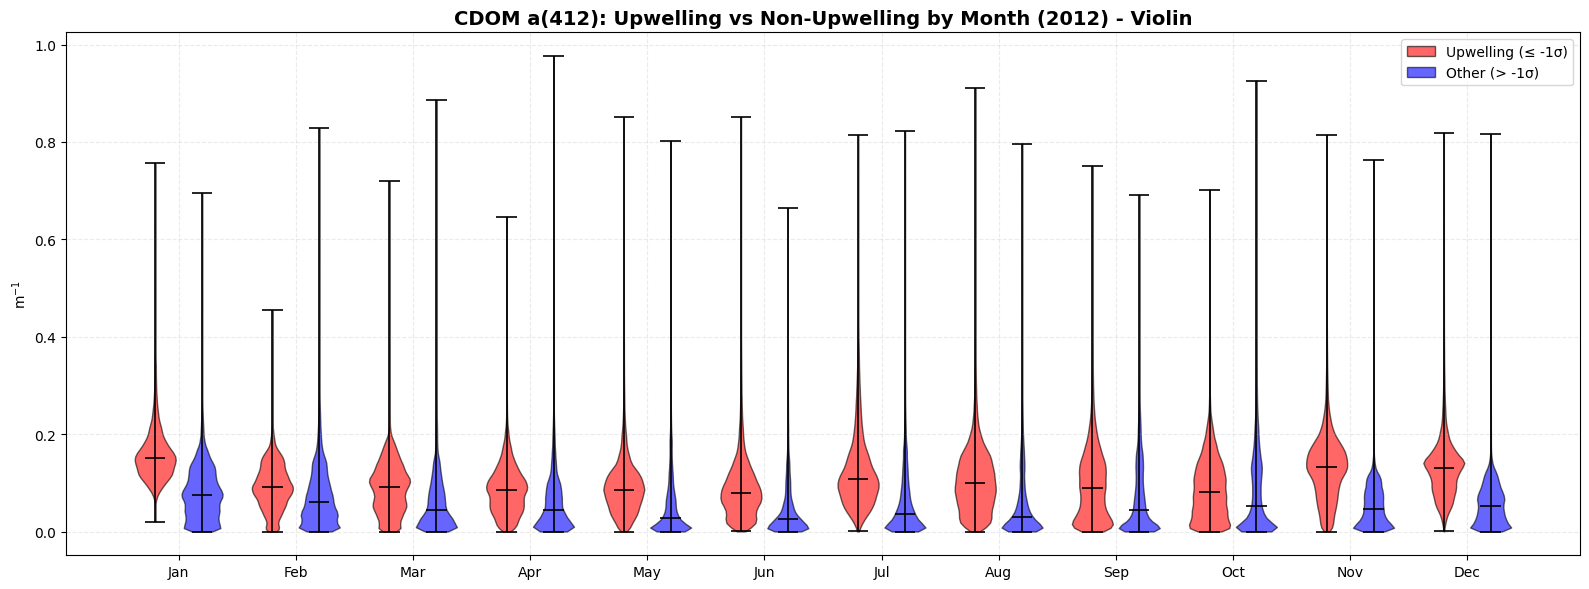

Generated violin plots for 2012.

Processing Year: 2013


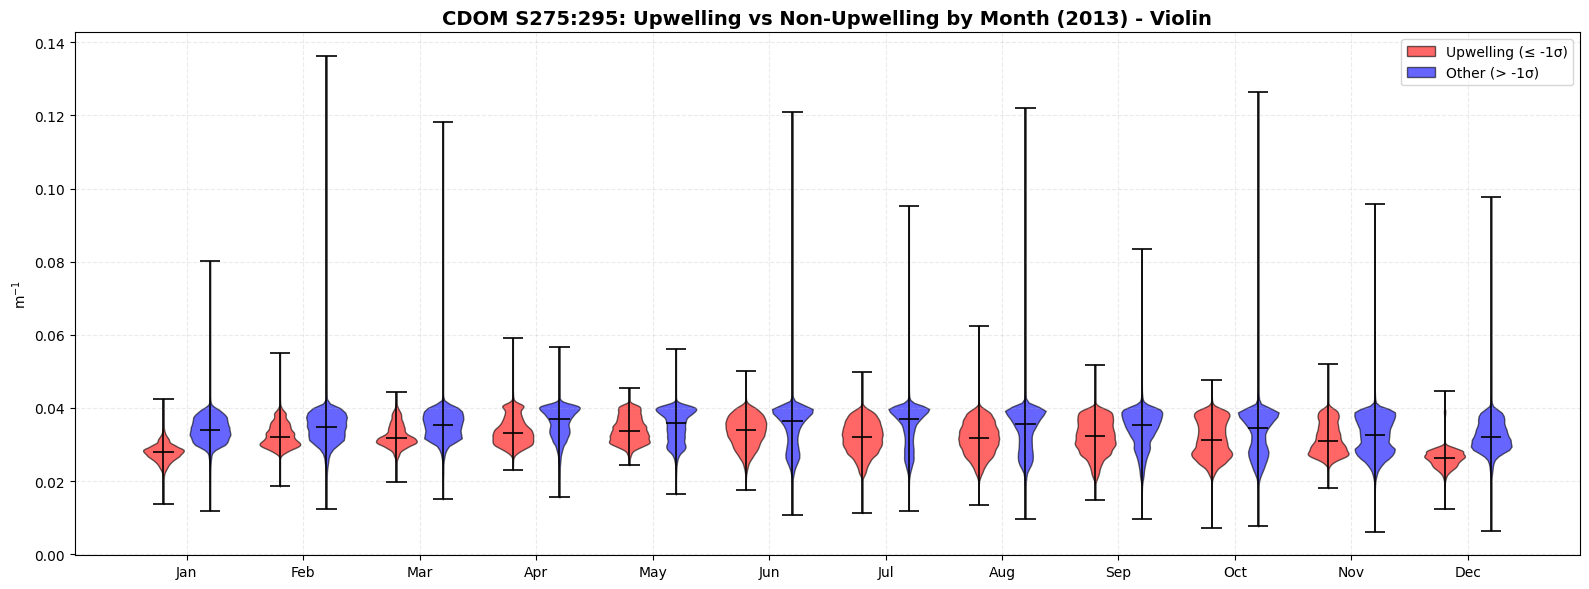

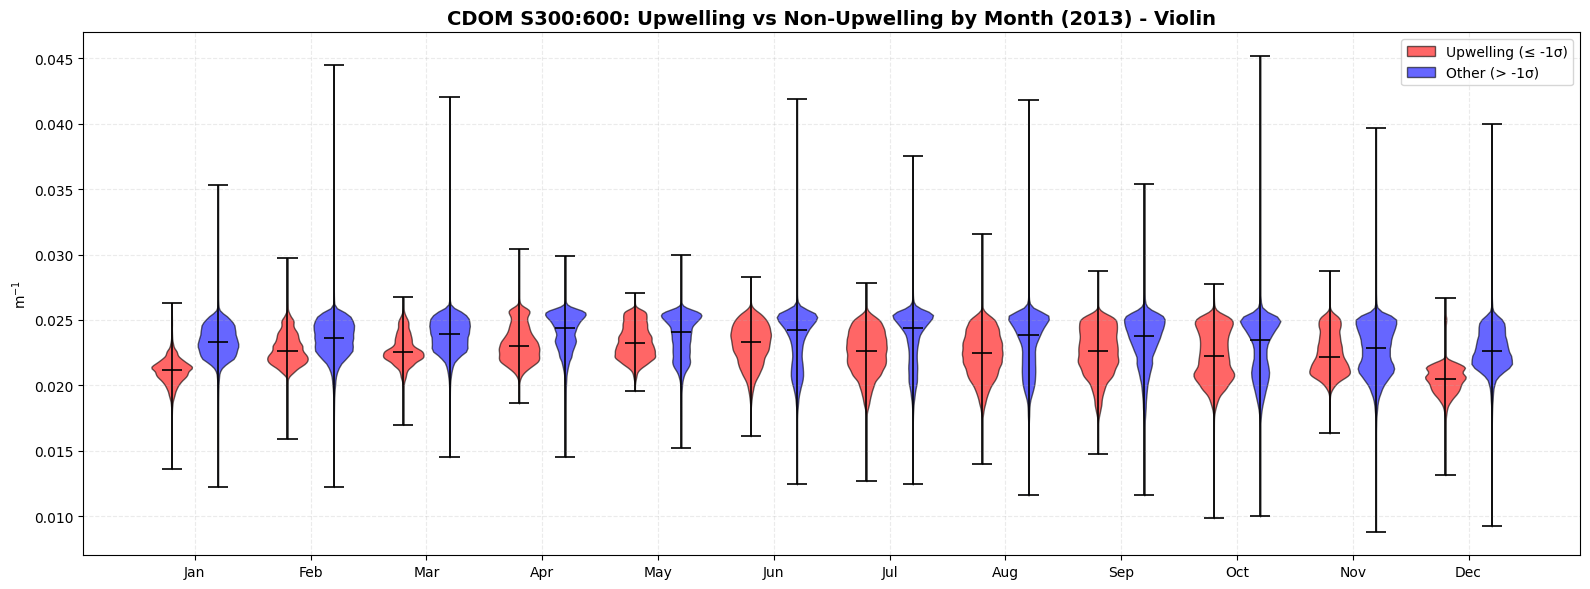

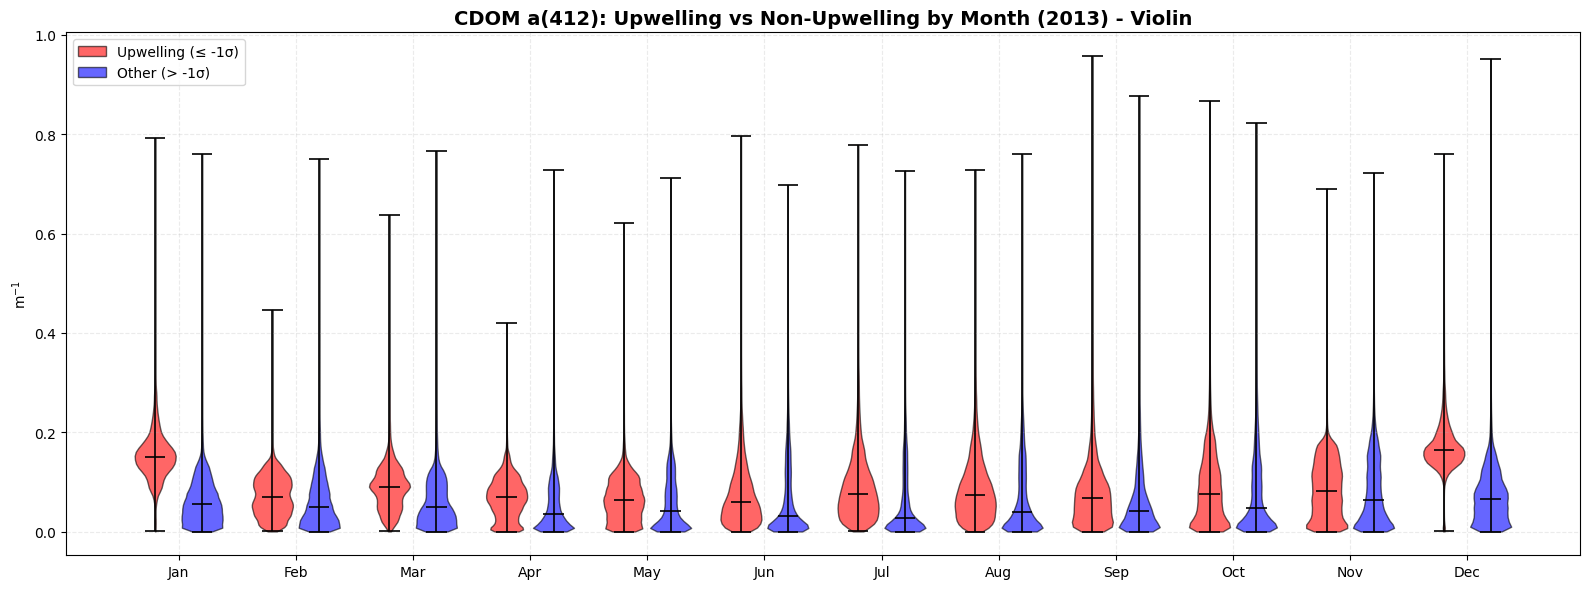

Generated violin plots for 2013.

Processing Year: 2014


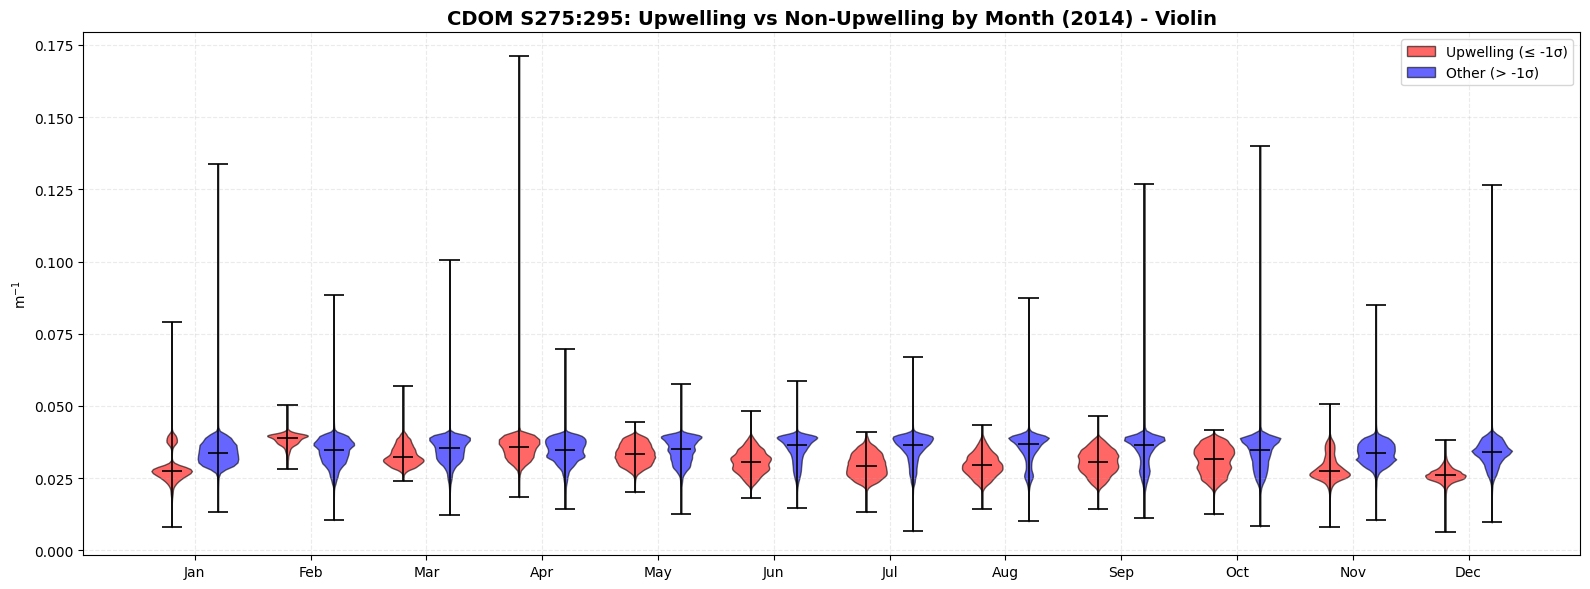

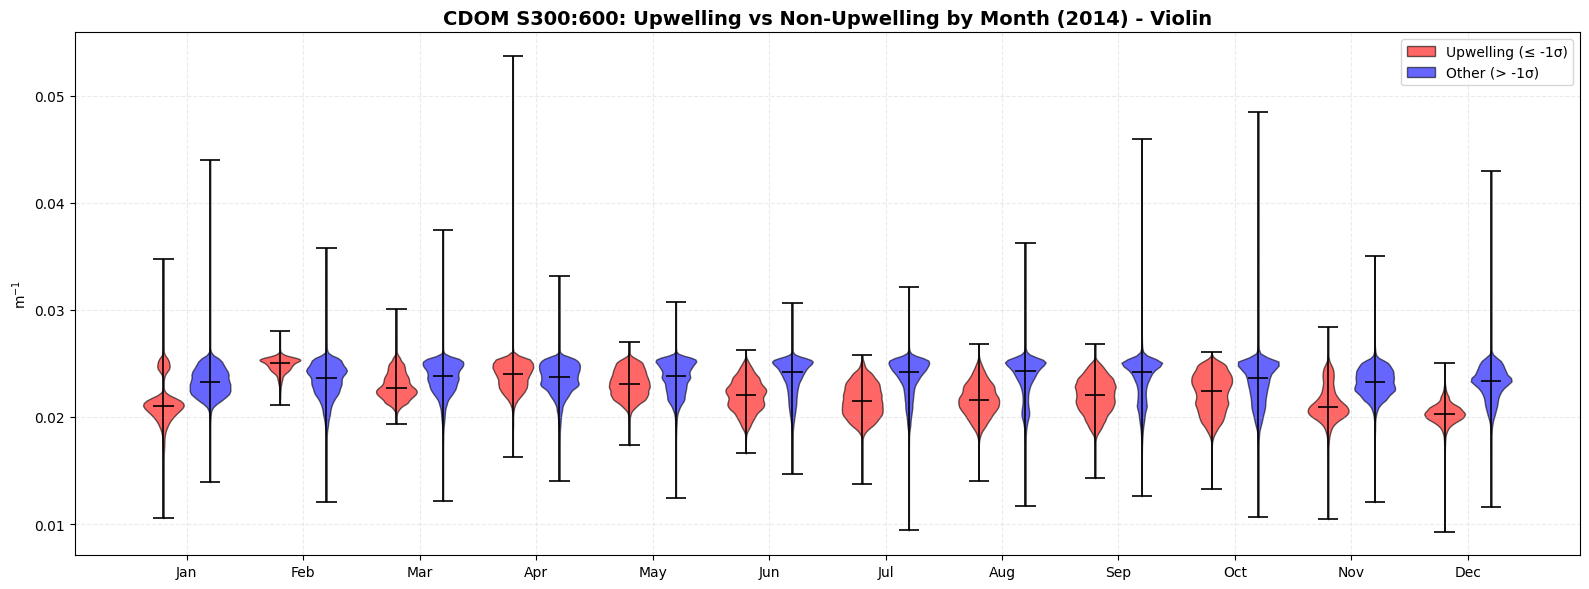

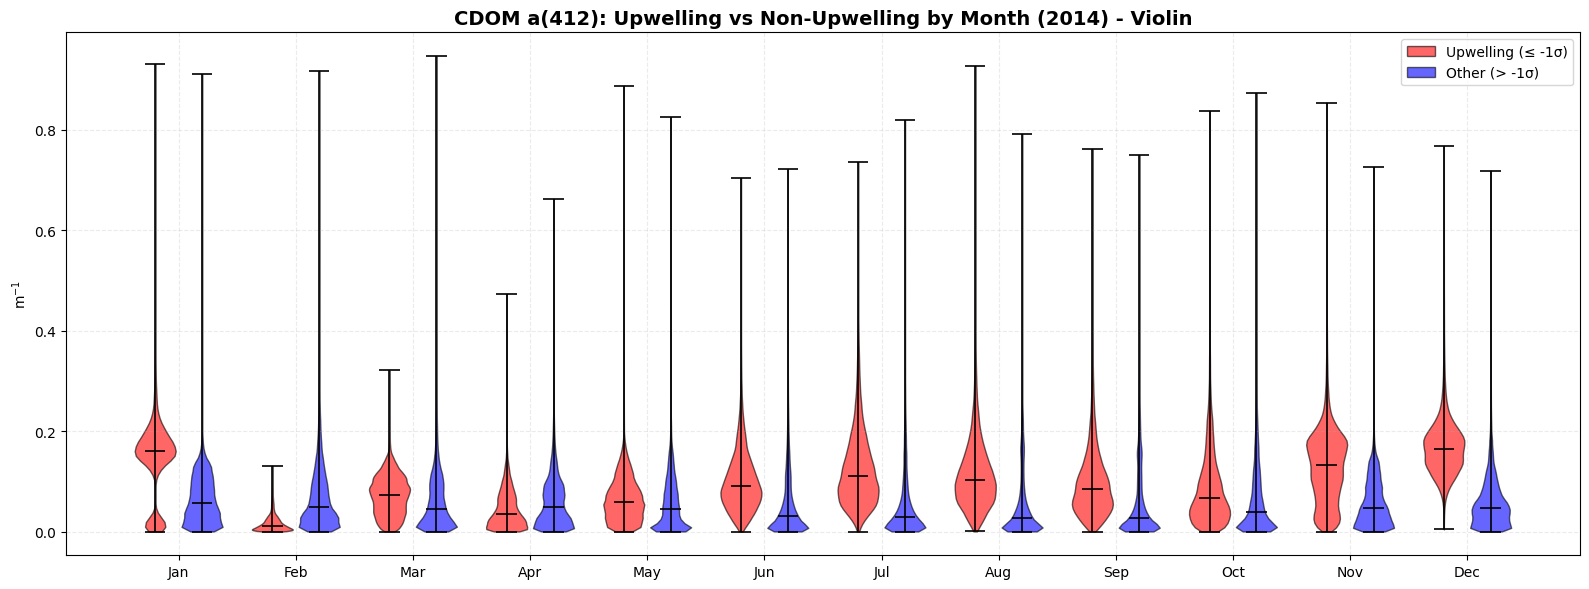

Generated violin plots for 2014.

Processing Year: 2015


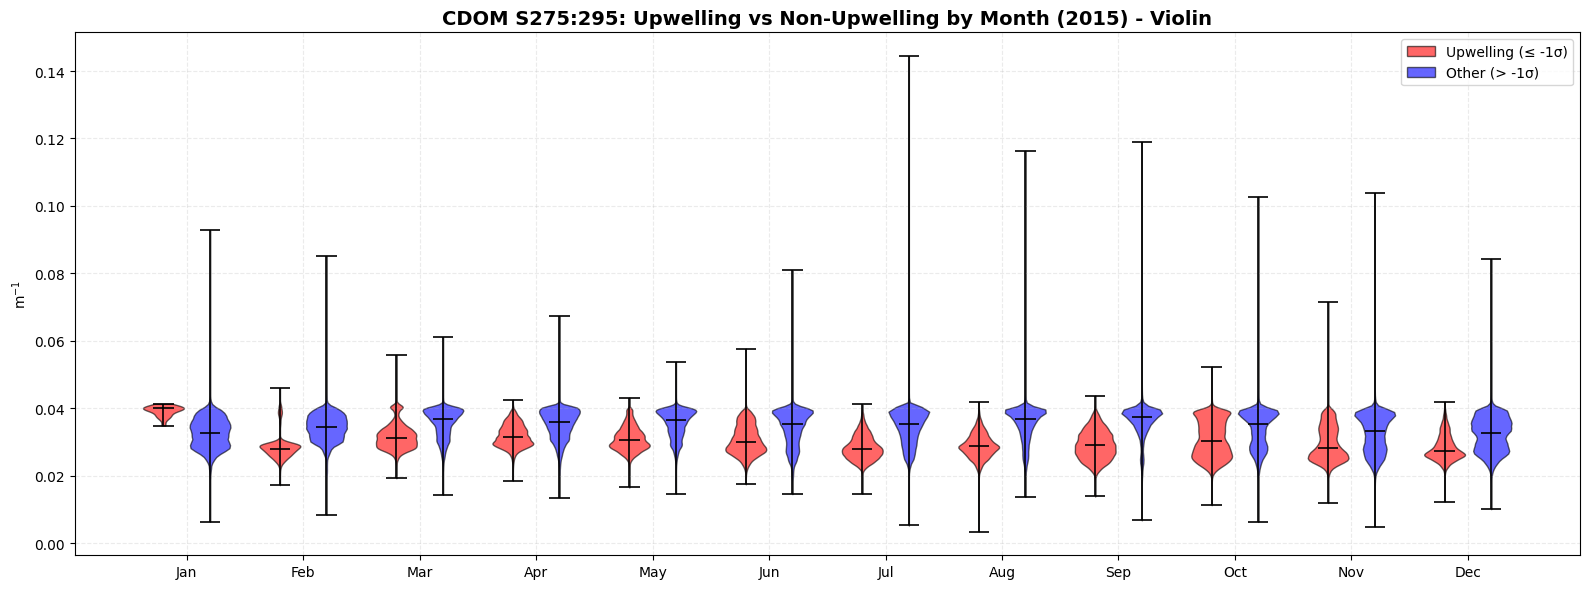

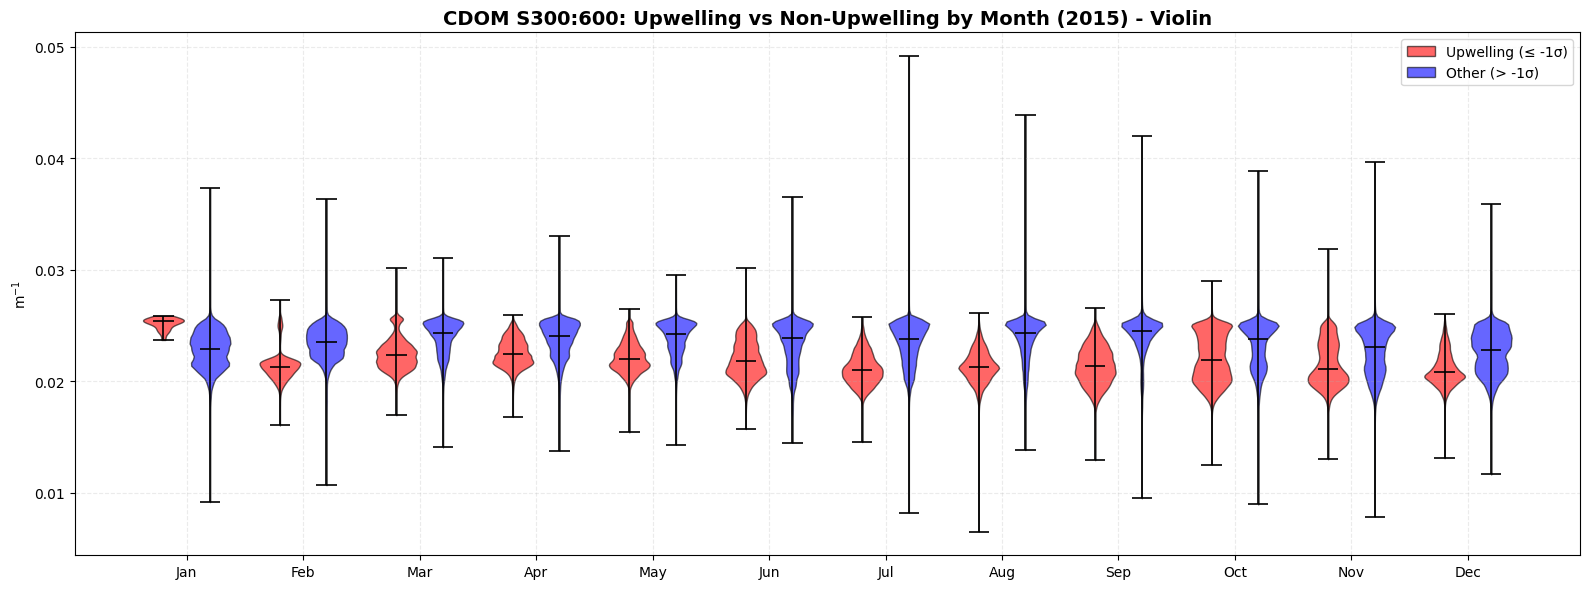

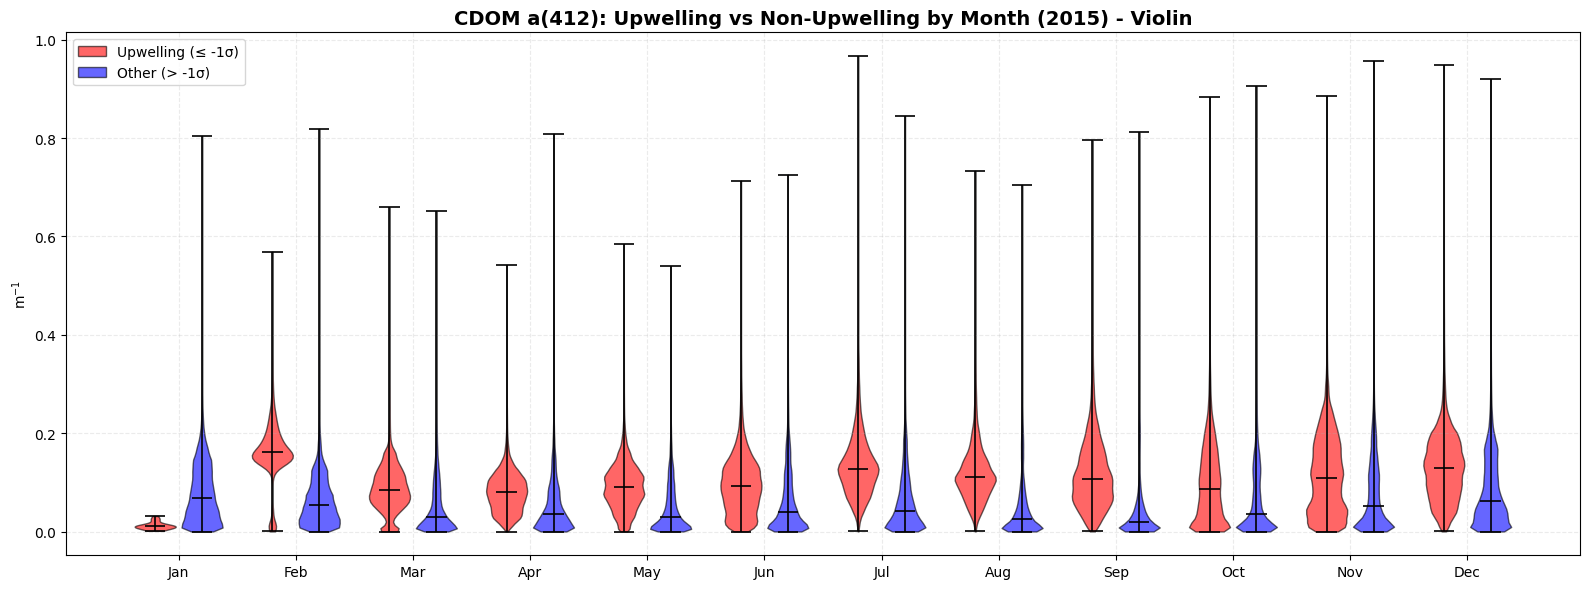

Generated violin plots for 2015.

Processing Year: 2016


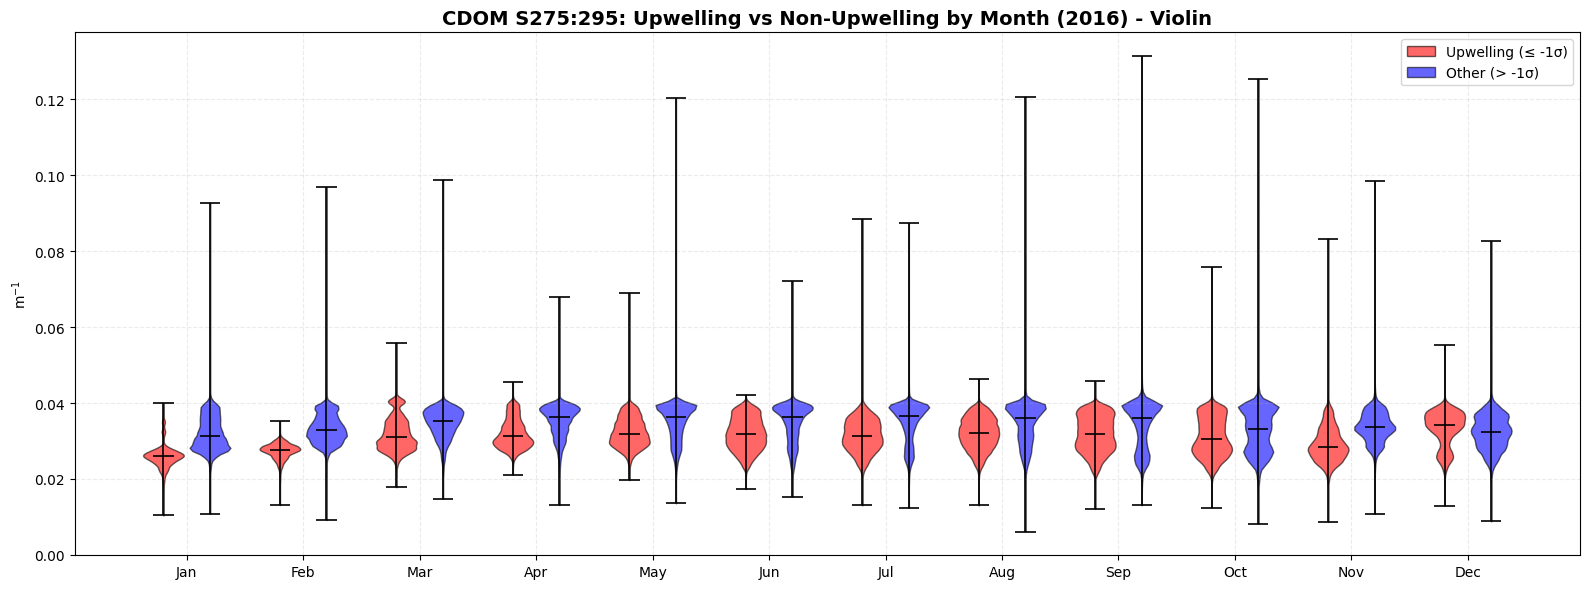

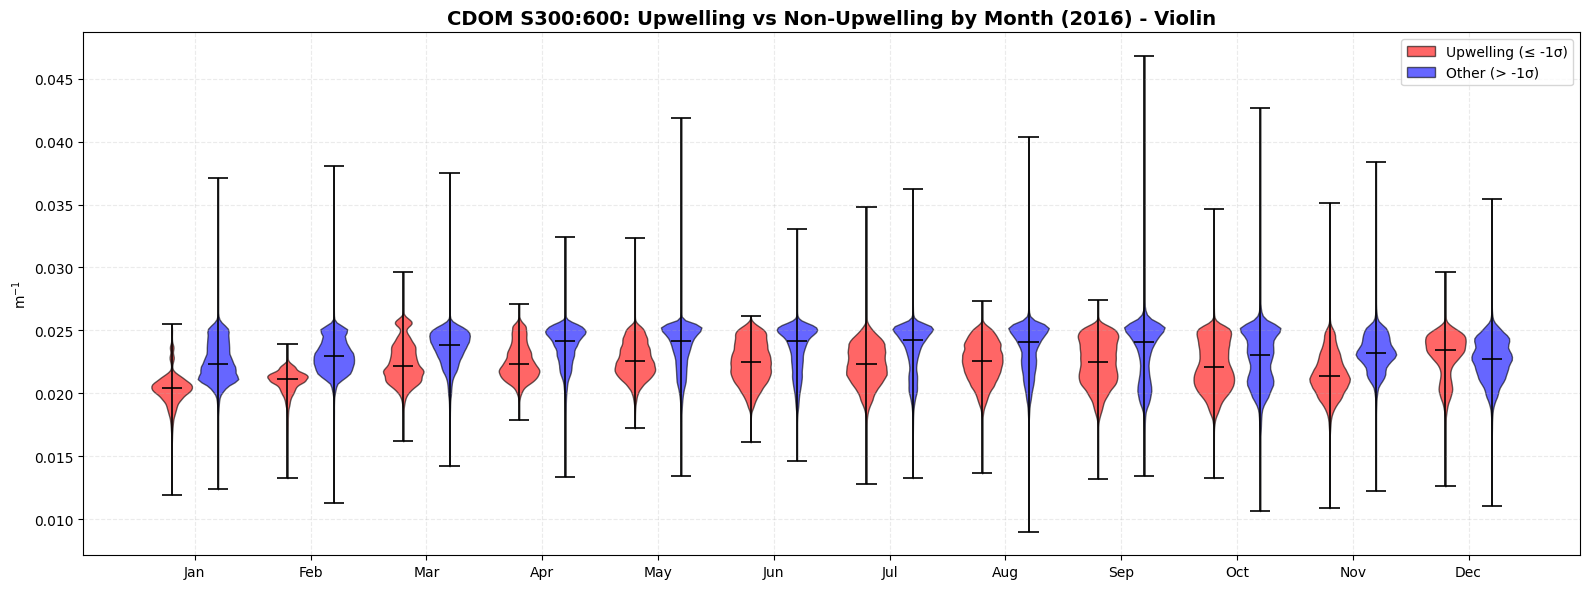

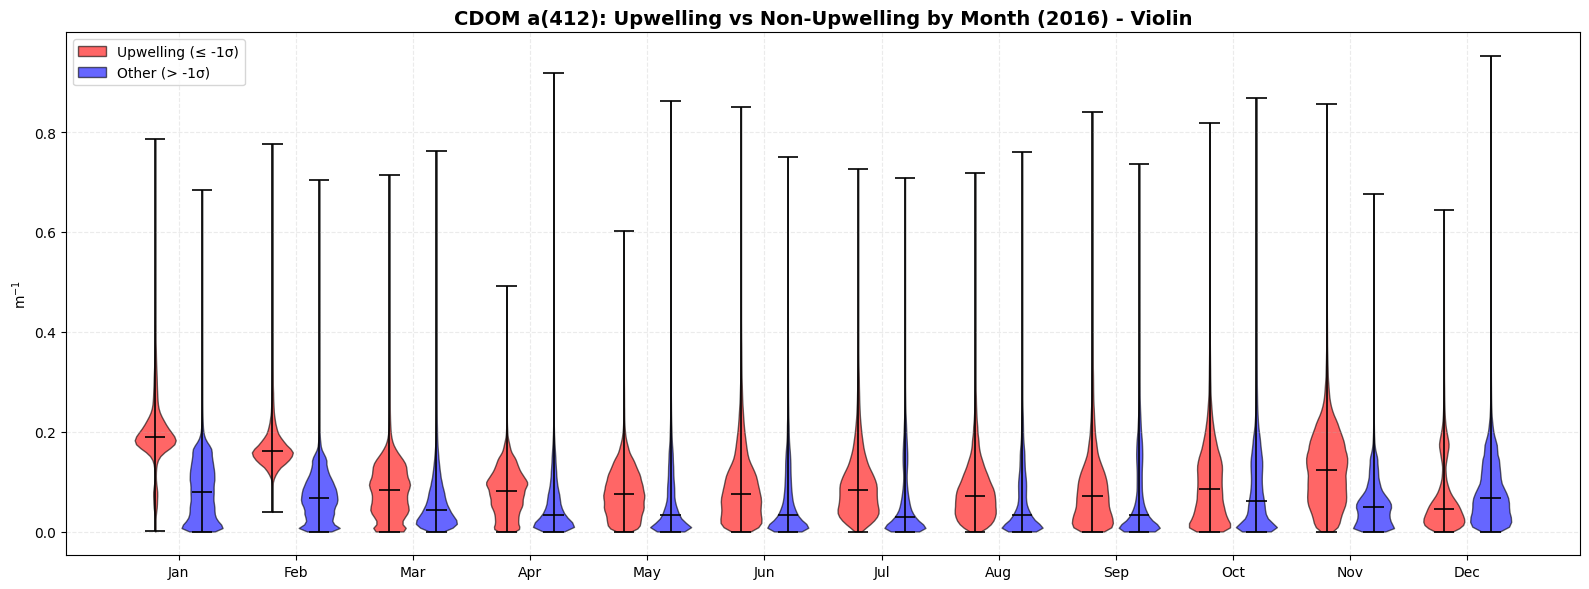

Generated violin plots for 2016.

Processing Year: 2017


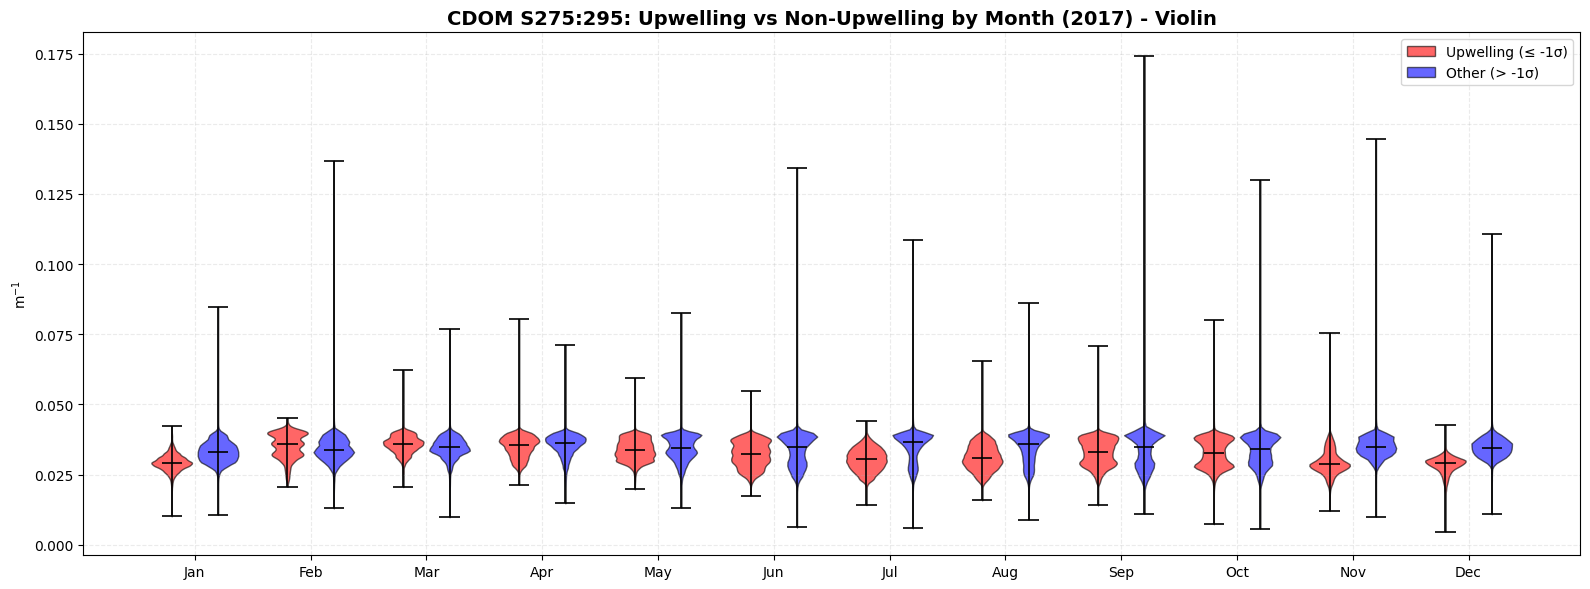

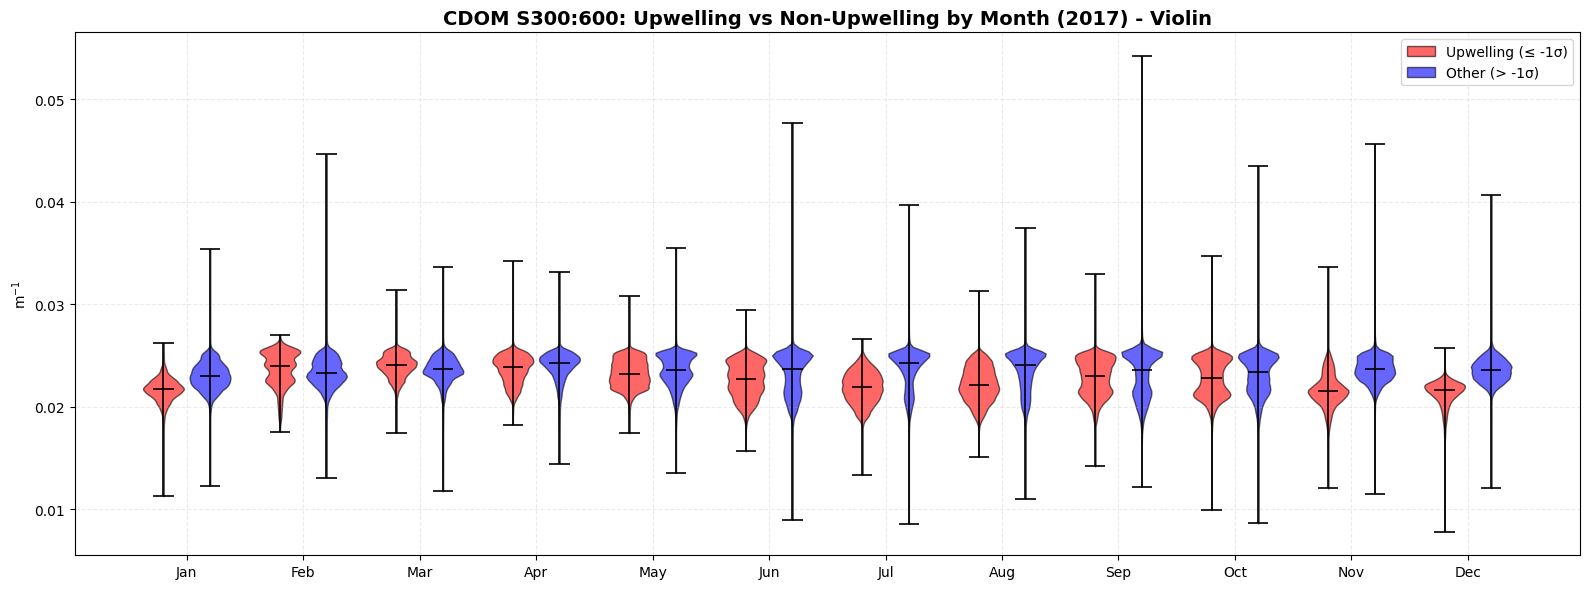

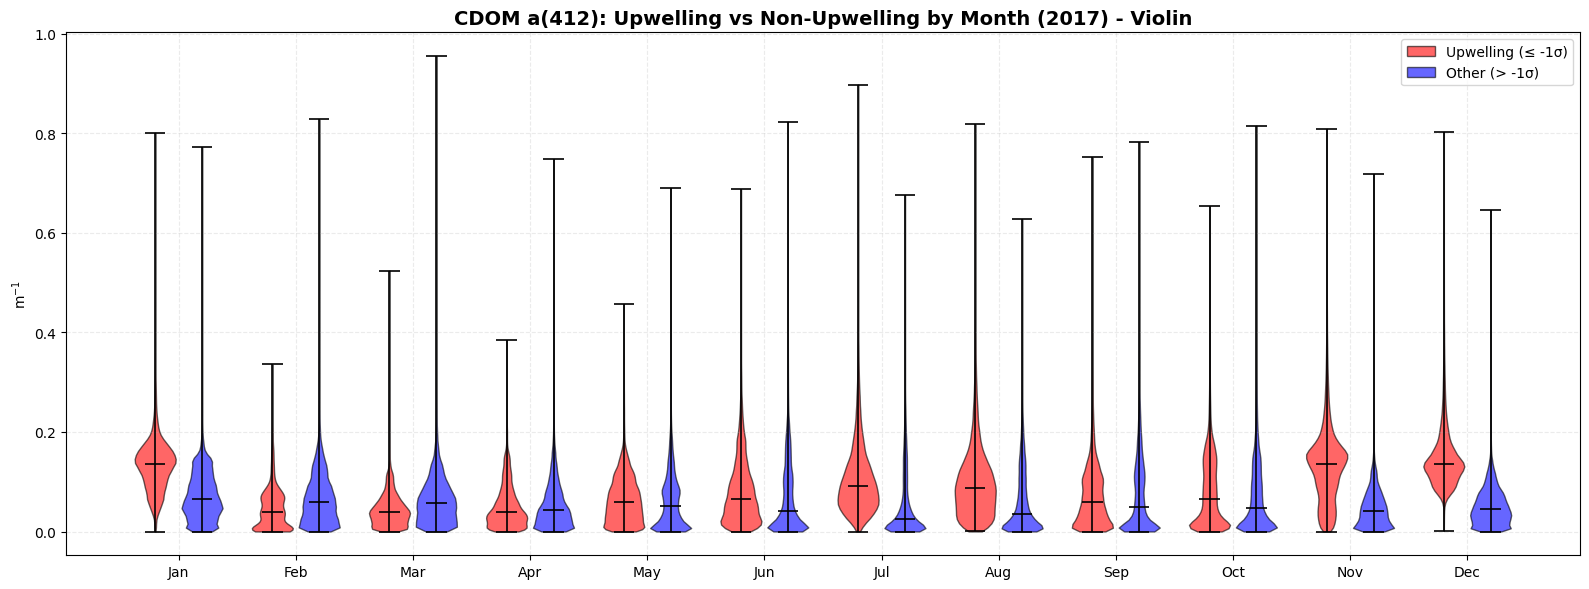

Generated violin plots for 2017.

Processing Year: 2018


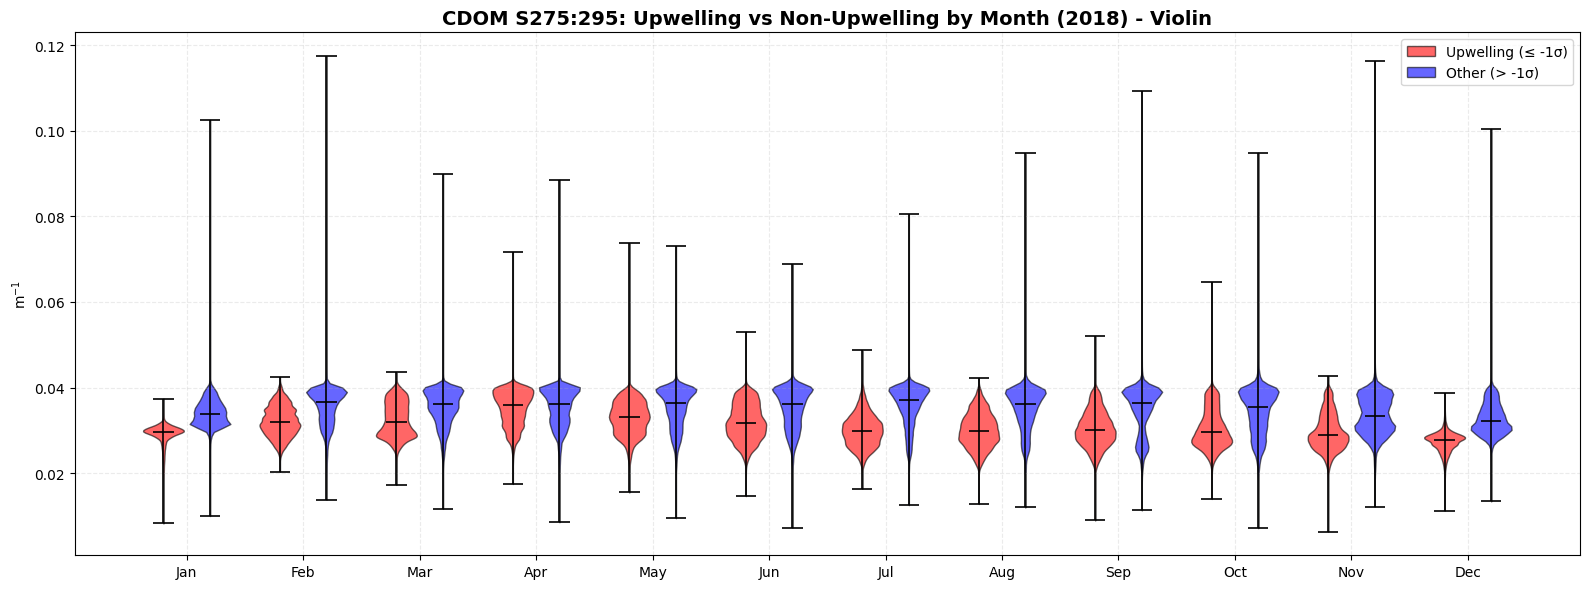

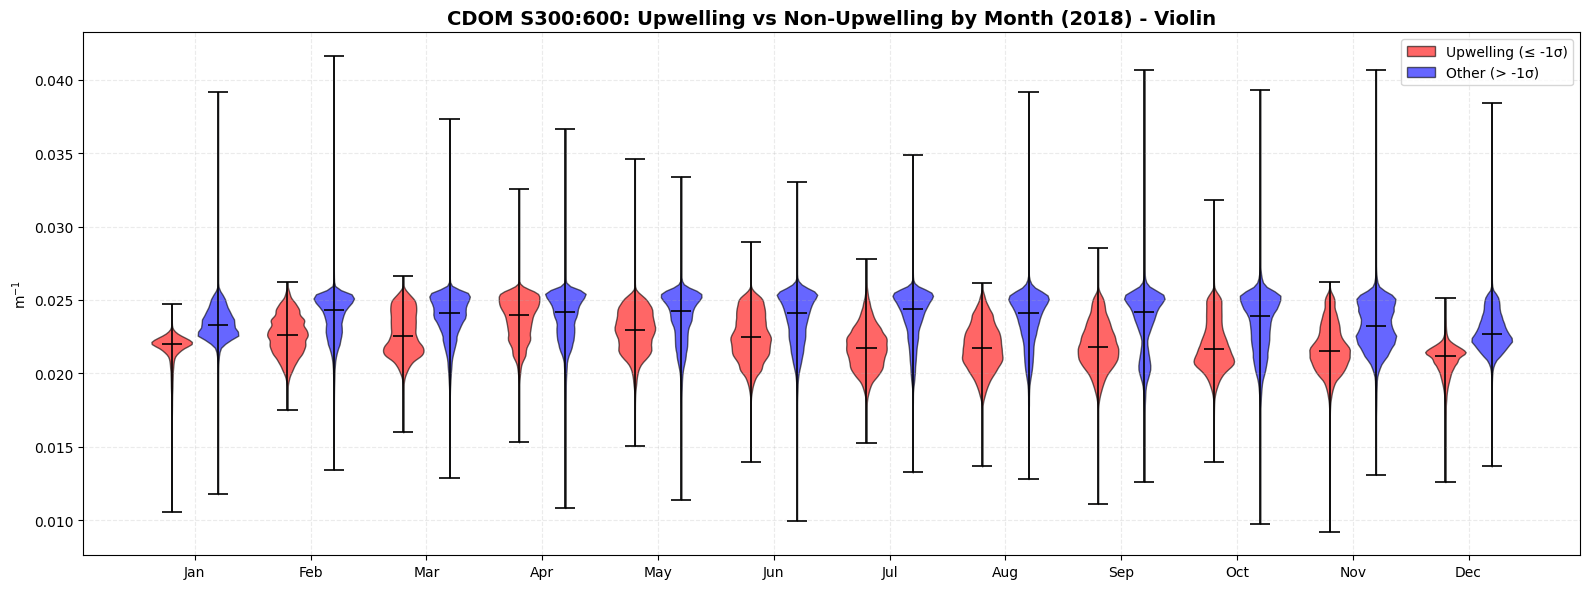

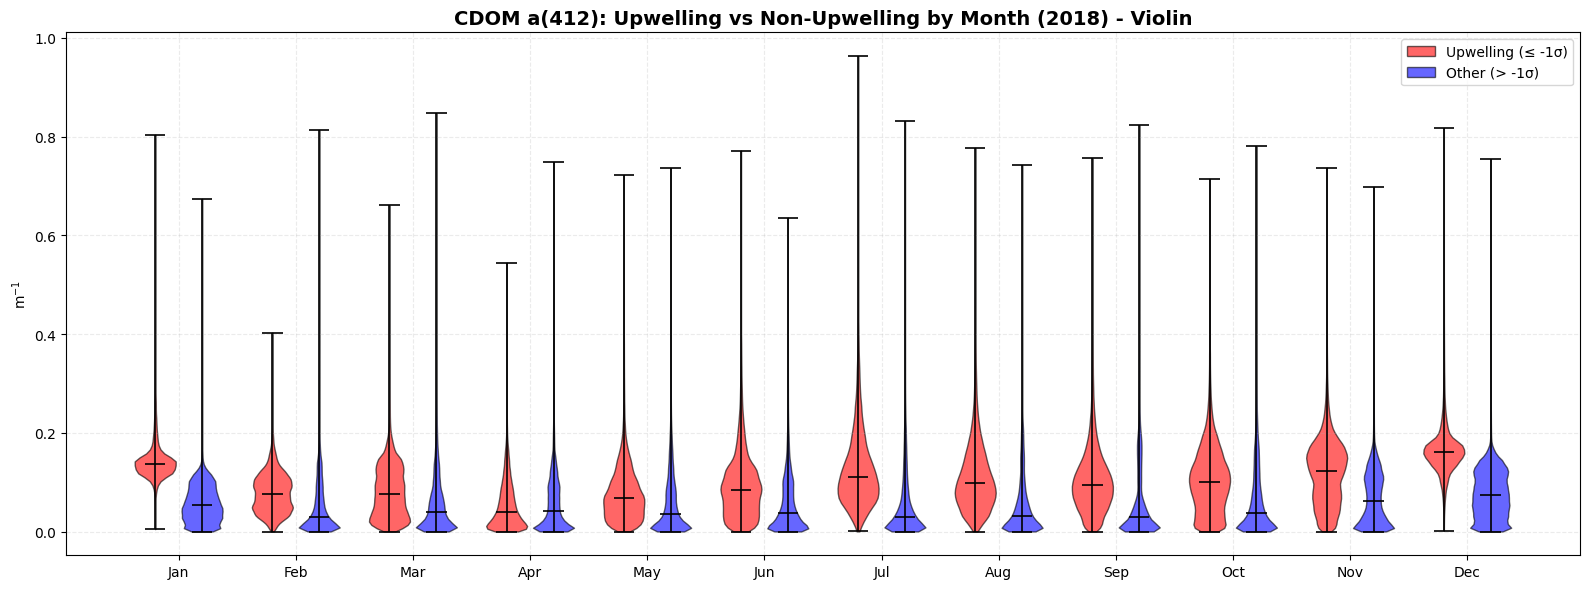

Generated violin plots for 2018.

Processing Year: 2019


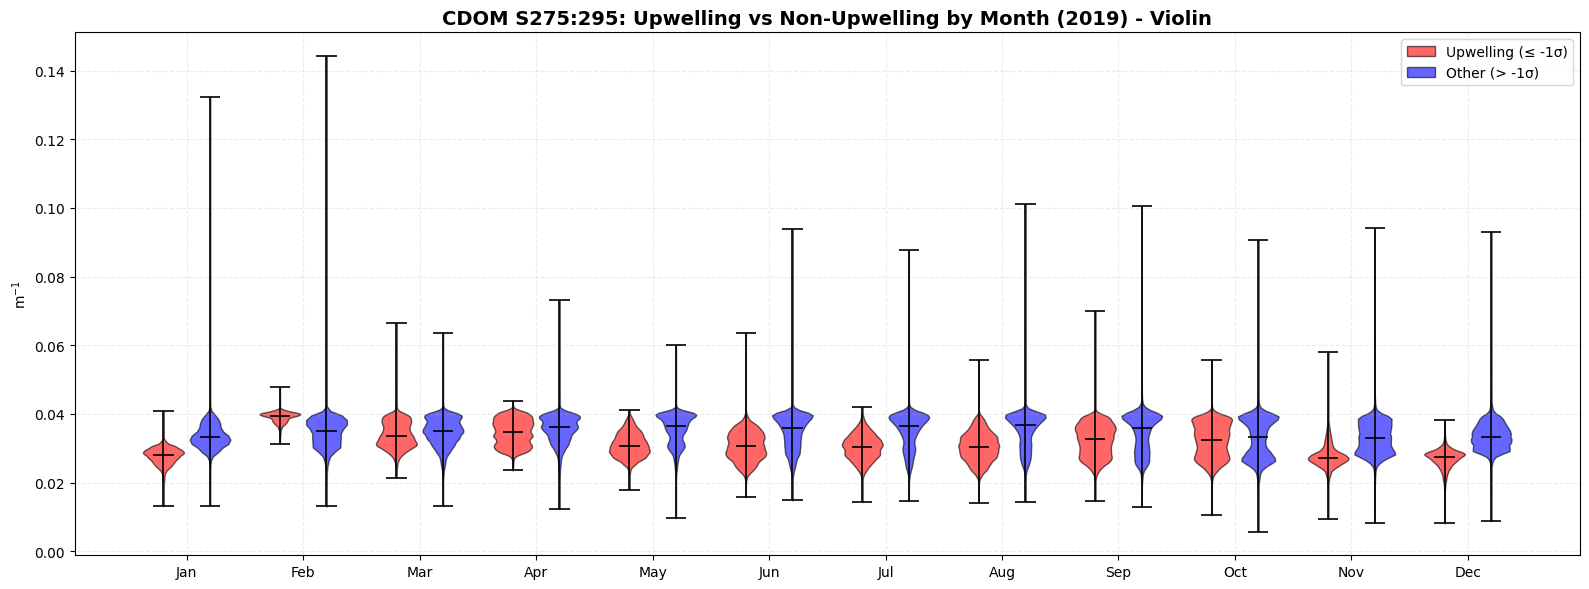

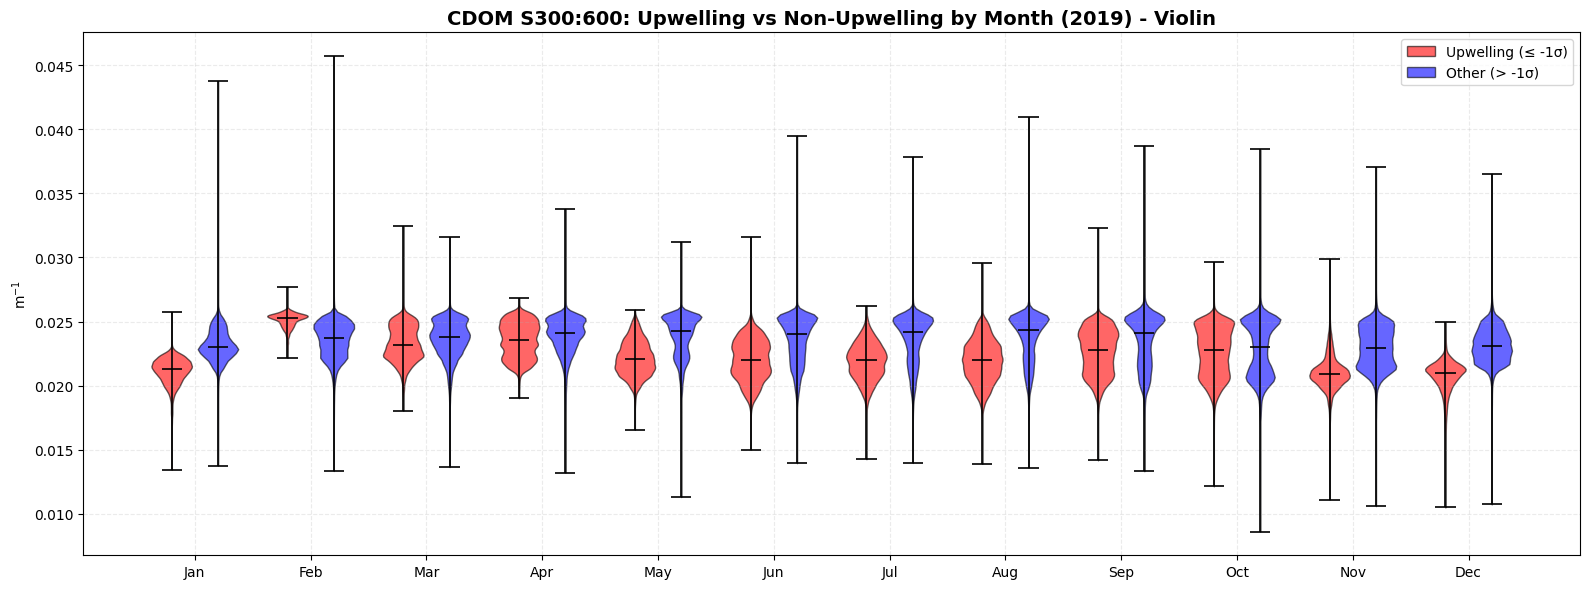

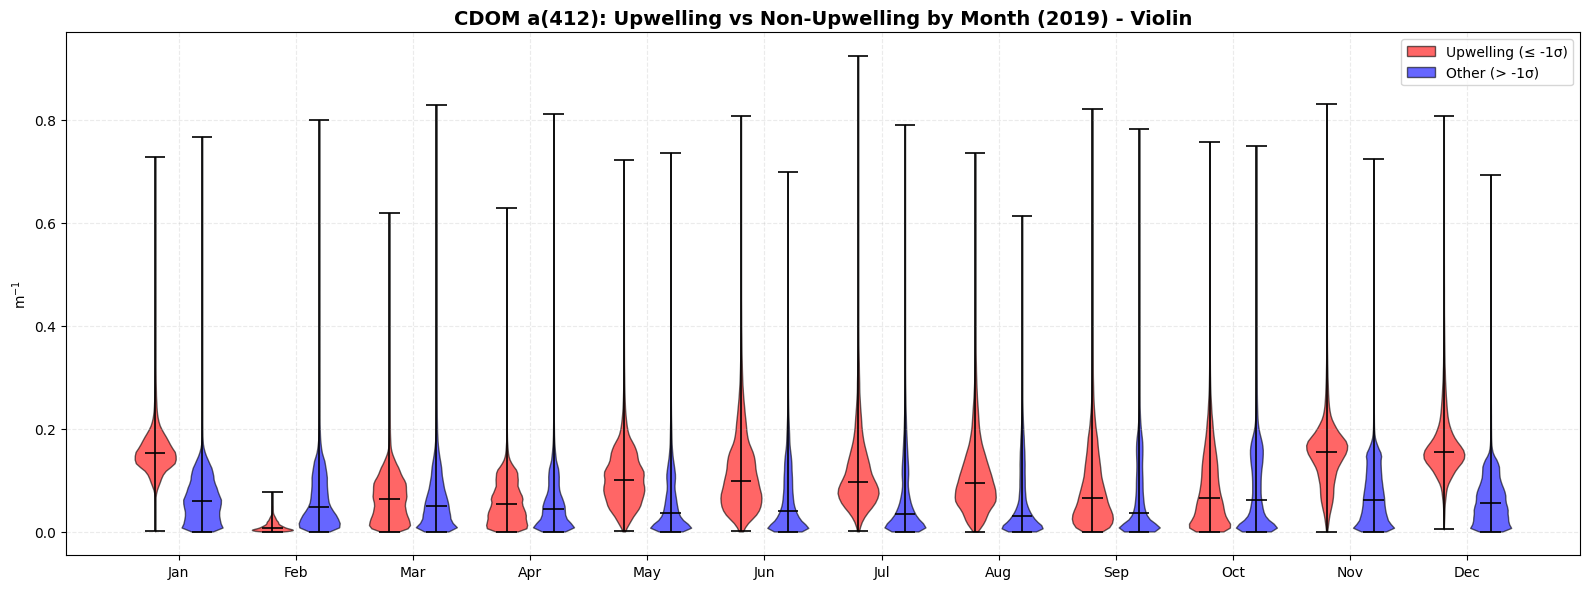

Generated violin plots for 2019.


In [3]:
# Process all years from 2010 to 2019
for year in range(2010, 2020):
    process_and_plot_year(year)